In [34]:
!pip install scipy tensorflow --quiet

In [35]:
!pip install ml_dtypes --upgrade --quiet

In [36]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.fft import rfft, rfftfreq
from scipy.signal import cont2discrete
from scipy.linalg import expm
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler


In [37]:
FILE = "/content/simulink_merged_sorted.csv"  # or '/content/simulink_merged_sorted.csv'
df = pd.read_csv(FILE)

# Quick look
print(df.shape)
print(df.columns)
df.head()

(100000, 7)
Index(['Time', 'Vin', 'Resistance1', 'Inductance', 'Capacitance', 'Diode_Vf',
       'Vout'],
      dtype='object')


,Time,Vin,Resistance1,Inductance,Capacitance,Diode_Vf,Vout
0,0.000000e+00,10.000703,5.000483,0.0005,0.00005,0.7,9.198318
1,0.000000e+00,20.000110,15.000163,0.0025,0.00015,0.7,16.458792
2,5.555617e-07,20.000357,15.000331,0.0025,0.00015,0.7,16.459051
3,1.111123e-06,20.000373,15.000490,0.0025,0.00015,0.7,16.458834
4,1.666685e-06,20.000483,15.001822,0.0025,0.00015,0.7,16.458705


In [38]:
df.tail()


,Time,Vin,Resistance1,Inductance,Capacitance,Diode_Vf,Vout
99995,0.049998,29.999506,29.999643,0.0090,0.00025,0.7,11.954605
99996,0.049999,29.999703,29.999655,0.0090,0.00025,0.7,11.954584
99997,0.049999,29.999707,29.999894,0.0090,0.00025,0.7,11.954584
99998,0.050000,19.997926,14.998393,0.0025,0.00015,0.7,16.457107
99999,0.050000,29.999728,29.999920,0.0090,0.00025,0.7,11.954478


Estimated sampling frequency fs_data = 1799980.00 Hz, dt = 5.555617e-07 s
Estimated switching frequency (FFT peak) = 179998.0 Hz


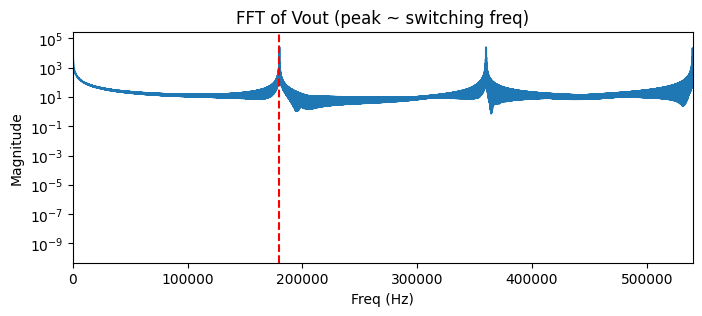

In [39]:
# time vector (assumes Time column exists in seconds)
t = df['Time'].values
dt = np.median(np.diff(t))   # robust
fs_data = 1.0 / dt
print(f"Estimated sampling frequency fs_data = {fs_data:.2f} Hz, dt = {dt:.6e} s")

# Use Vout to find switching frequency via FFT
vo = df['Vout'].values - np.mean(df['Vout'].values)  # remove DC
Nfft = min(len(vo), 200000)   # limit size for FFT speed
y = vo[:Nfft]
Y = np.abs(rfft(y))
freqs = rfftfreq(len(y), dt)
# ignore very low frequencies; look at high freq peak (switching)
fmin = int(len(freqs)*0.01)
peak_idx = np.argmax(Y[fmin:]) + fmin
f_switch_est = freqs[peak_idx]
print(f"Estimated switching frequency (FFT peak) = {f_switch_est:.1f} Hz")

# Visual quick plot (optional)
plt.figure(figsize=(8,3))
plt.semilogy(freqs, Y + 1e-12)
plt.xlim(0, f_switch_est*3)
plt.axvline(f_switch_est, color='r', linestyle='--')
plt.xlabel('Freq (Hz)'); plt.ylabel('Magnitude'); plt.title('FFT of Vout (peak ~ switching freq)')
plt.show()


In [40]:
# Samples per switching period (rounded)
N_per = int(np.round(fs_data / f_switch_est))
if N_per < 2:
    raise RuntimeError("Detected samples per switching period too small. Re-estimate switching freq or check data.")
print("Samples per switching period N_per =", N_per)

# Truncate to multiple of N_per
n_periods = len(df) // N_per
n_used = n_periods * N_per
df_trunc = df.iloc[:n_used].copy().reset_index(drop=True)

# reshape arrays to compute per-period averages
def period_average(arr):
    arr2 = arr.reshape((n_periods, N_per))
    return arr2.mean(axis=1), arr2.var(axis=1)

Vout_inst = df_trunc['Vout'].values
Vin_inst  = df_trunc['Vin'].values
R_inst    = df_trunc['Resistance1'].values
L_inst    = df_trunc['Inductance'].values
C_inst    = df_trunc['Capacitance'].values
Diode_vf  = df_trunc['Diode_Vf'].values

Vout_avg, Vout_var = period_average(Vout_inst)
Vin_avg, Vin_var   = period_average(Vin_inst)
R_avg, R_var       = period_average(R_inst)
L_avg, L_var       = period_average(L_inst)
C_avg, C_var       = period_average(C_inst)
# time per averaged sample
t_avg = t[:n_used].reshape((n_periods, N_per)).mean(axis=1)

print("Averaged series length:", len(Vout_avg))


Samples per switching period N_per = 10
Averaged series length: 10000


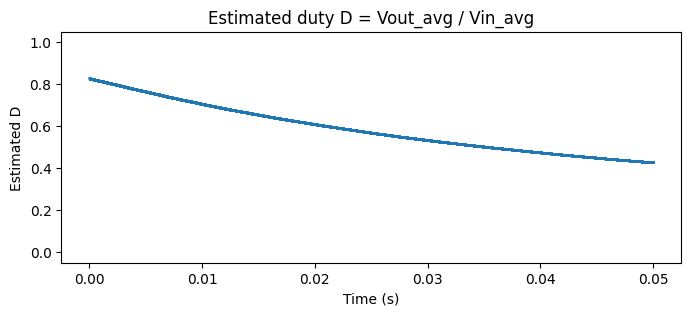

In [41]:
D_est = Vout_avg / (Vin_avg + 1e-12)  # avoid div0
# Bound D between 0 and 1
D_est = np.clip(D_est, 0.0, 1.0)

plt.figure(figsize=(8,3))
plt.plot(t_avg, D_est, '.', markersize=2)
plt.xlabel('Time (s)'); plt.ylabel('Estimated D'); plt.title('Estimated duty D = Vout_avg / Vin_avg')
plt.ylim(-0.05,1.05)
plt.show()



In [42]:
from scipy.signal import cont2discrete

K = len(Vout_avg)
Ad_list = []
Bd_list = []
Cd = np.array([[0., 1.]])
Dd0 = np.zeros((1,1))

Ts = np.median(np.diff(t_avg))
print("Averaged Ts =", Ts)

for k in range(K):
    Lk = L_avg[k] if L_avg[k] > 0 else L_avg.max()
    Ck = C_avg[k] if C_avg[k] > 0 else C_avg.max()
    Rk = R_avg[k] if R_avg[k] > 0 else R_avg.max()
    Vin_k = Vin_avg[k]
    Ac = np.array([[0.0, -1.0 / Lk],
                   [1.0 / Ck, -1.0 / (Rk * Ck)]])
    Bc = np.array([[Vin_k / Lk],
                   [0.0]])
    sysd = cont2discrete((Ac, Bc, Cd, Dd0), Ts, method='zoh')
    Ad_list.append(sysd[0])
    Bd_list.append(sysd[1])


Averaged Ts = 5.000100005557451e-06


In [43]:
# Prepare inputs and measurements for KF
U = D_est.reshape(-1,1)    # input sequence per averaged sample
Y = Vout_avg.reshape(-1,1)

n_states = 2
n_meas = 1
# initial state and covariance
x_hat = np.zeros((n_states,))   # or small initial guess
P = np.eye(n_states) * 1e-3

# measurement noise covariance Rk: compute empirical variance of averaged samples (or use mean of within-period variances)
meas_var_emp = np.var(Y.flatten(), ddof=1)
# Alternatively estimate measurement noise from within-period variance / N_per
meas_var_within = np.mean(Vout_var) / N_per
print("Empirical var(Vout_avg) =", meas_var_emp, "approx meas var from within periods/N =", meas_var_within)
Rk = np.array([[max(meas_var_within, 1e-6)]])  # safe floor

# process noise Q: tuneable
Q = np.diag([1e-6, 1e-6])  # start small - increase if mismatch shows up

# storage
x_hat_hist = np.zeros((K, n_states))
P_hist = np.zeros((K, n_states, n_states))
residuals = np.zeros((K, n_meas))

for k in range(K):
    Ad = Ad_list[k]
    Bd = Bd_list[k]
    uk = np.array([U[k,0]])
    # Predict
    x_pred = Ad.dot(x_hat) + Bd.dot(uk)
    P_pred = Ad.dot(P).dot(Ad.T) + Q
    # Update
    y_pred = Cd.dot(x_pred).reshape(-1)
    sk = Cd.dot(P_pred).dot(Cd.T) + Rk
    Kk = P_pred.dot(Cd.T).dot(np.linalg.inv(sk))
    y_meas = Y[k].reshape(-1)
    innov = y_meas - y_pred
    x_hat = x_pred + (Kk.dot(innov)).flatten()
    P = (np.eye(n_states) - Kk.dot(Cd)).dot(P_pred)
    # store
    x_hat_hist[k,:] = x_hat
    P_hist[k,:,:] = P
    residuals[k,:] = innov   # measurement residual (innovation)


Empirical var(Vout_avg) = 0.953255923892021 approx meas var from within periods/N = 0.10790784778052867


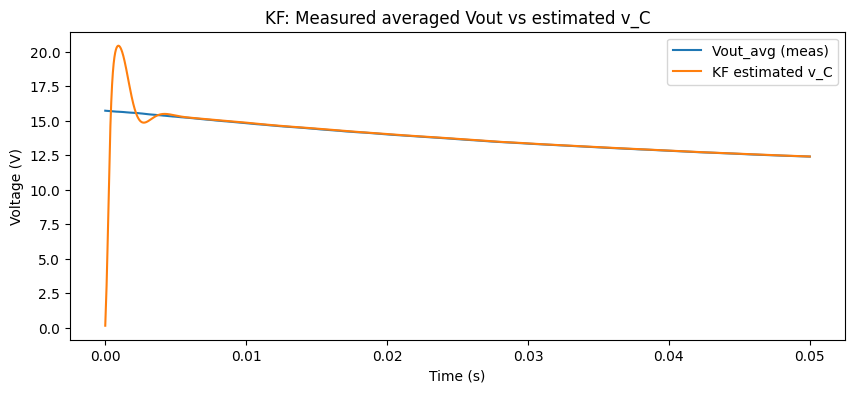

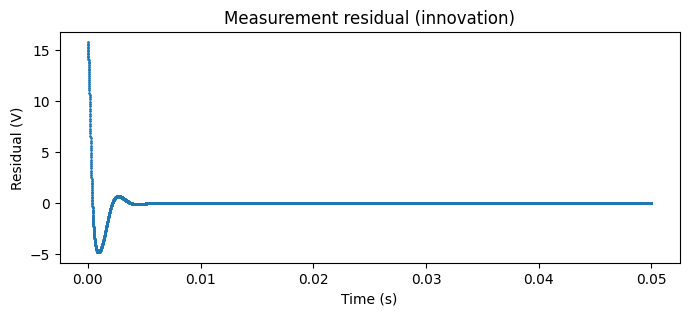

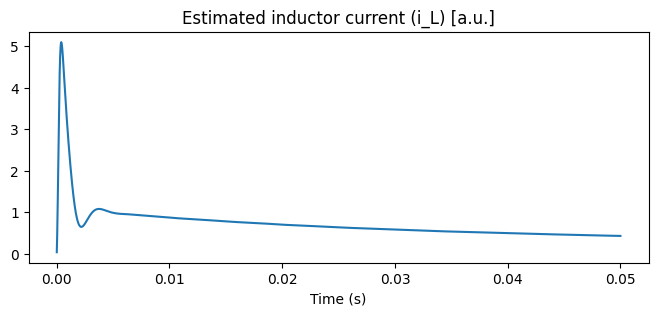

In [44]:
plt.figure(figsize=(10,4))
plt.plot(t_avg, Y, label='Vout_avg (meas)')
plt.plot(t_avg, x_hat_hist[:,1], label='KF estimated v_C')
plt.legend(); plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('KF: Measured averaged Vout vs estimated v_C'); plt.show()

# Residual plot
plt.figure(figsize=(8,3))
plt.plot(t_avg, residuals, '.', markersize=2)
plt.title('Measurement residual (innovation)')
plt.xlabel('Time (s)'); plt.ylabel('Residual (V)'); plt.show()

# Example: inspect estimated i_L
plt.figure(figsize=(8,3))
plt.plot(t_avg, x_hat_hist[:,0])
plt.title('Estimated inductor current (i_L) [a.u.]'); plt.xlabel('Time (s)'); plt.show()


In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate RMSE and MAE
# We will use the original Vout_avg as the 'true' value for comparison
rmse = np.sqrt(mean_squared_error(Y.flatten(), x_hat_hist[:, 1]))
mae = mean_absolute_error(Y.flatten(), x_hat_hist[:, 1])

# Calculate Percentage Error
# Avoid division by zero by adding a small epsilon
percentage_error = np.mean(np.abs((Y.flatten() - x_hat_hist[:, 1]) / (Y.flatten() + 1e-9))) * 100

print(f"Kalman Filter Performance Metrics:")
print(f"RMSE (Vout_avg vs estimated v_C): {rmse:.4f}")
print(f"MAE (Vout_avg vs estimated v_C): {mae:.4f}")
print(f"Mean Percentage Error (Vout_avg vs estimated v_C): {percentage_error:.2f}%")

Kalman Filter Performance Metrics:
RMSE (Vout_avg vs estimated v_C): 1.0508
MAE (Vout_avg vs estimated v_C): 0.2001
Mean Percentage Error (Vout_avg vs estimated v_C): 1.29%


In [46]:
import scipy.stats as stats
def compute_metrics(y_true, y_est):
    rmse = np.sqrt(mean_squared_error(y_true, y_est))
    mae = mean_absolute_error(y_true, y_est)
    # MAPE but avoid zero division
    eps = 1e-9
    mape = np.mean(np.abs((y_true - y_est) / (np.abs(y_true) + eps))) * 100.0
    nrmse = rmse / (np.max(y_true) - np.min(y_true) + eps)
    return {'rmse': rmse, 'mae': mae, 'mape_pct': mape, 'nrmse': nrmse}

def residual_anomaly_scores(residuals):
    # z-score of residuals and proportion of large z
    res = residuals.flatten()
    z = stats.zscore(res)
    # if constant residuals, zscore may be nan -> handle
    z = np.nan_to_num(z)
    return z, np.abs(z)  # we can threshold abs(z)>3


In [47]:
compute_metrics(Y.flatten(), x_hat_hist[:, 1])

{'rmse': np.float64(1.0507523239069227),
 'mae': 0.20008360172848222,
 'mape_pct': np.float64(1.291696009510098),
 'nrmse': np.float64(0.3157589116561104)}

In [48]:
# Augment example (outline) - implement similarly by re-building Ad_list/Bd_list for 3-state model
# For brevity, not fully re-coded here, but idea:
# measurement: y = [0 1 1] x_a  (v_C + b)
# b_{k+1} = b_k + w_b  (random walk)


GUASSIAN WHITE NOISE (REAL SCENARIO CONSISTING OF SENSOR NOISE)

In [49]:
sigma_vo = 0.02 * np.mean(Vout_avg)  # 2% noise
Vout_noisy = Vout_avg + np.random.normal(0, sigma_vo, size=Vout_avg.shape)


In [50]:
# Prepare inputs and measurements for KF
U = D_est.reshape(-1,1)    # input sequence per averaged sample
Y_n = Vout_noisy.reshape(-1,1)

n_states = 2
n_meas = 1
# initial state and covariance
x_hat = np.zeros((n_states,))   # or small initial guess
P = np.eye(n_states) * 1e-3

# measurement noise covariance Rk: compute empirical variance of averaged samples (or use mean of within-period variances)
meas_var_emp = np.var(Y_n.flatten(), ddof=1)
# Alternatively estimate measurement noise from within-period variance / N_per
meas_var_within = np.mean(Vout_var) / N_per
print("Empirical var(Vout_avg) =", meas_var_emp, "approx meas var from within periods/N =", meas_var_within)
Rk = np.array([[max(meas_var_within, 1e-6)]])  # safe floor

# process noise Q: tuneable
Q = np.diag([1e-6, 1e-6])  # start small - increase if mismatch shows up

# storage
x_hat_hist = np.zeros((K, n_states))
P_hist = np.zeros((K, n_states, n_states))
residuals = np.zeros((K, n_meas))

for k in range(K):
    Ad = Ad_list[k]
    Bd = Bd_list[k]
    uk = np.array([U[k,0]])
    # Predict
    x_pred = Ad.dot(x_hat) + Bd.dot(uk)
    P_pred = Ad.dot(P).dot(Ad.T) + Q
    # Update
    y_pred = Cd.dot(x_pred).reshape(-1)
    sk = Cd.dot(P_pred).dot(Cd.T) + Rk
    Kk = P_pred.dot(Cd.T).dot(np.linalg.inv(sk))
    y_meas = Y[k].reshape(-1)
    innov = y_meas - y_pred
    x_hat = x_pred + (Kk.dot(innov)).flatten()
    P = (np.eye(n_states) - Kk.dot(Cd)).dot(P_pred)
    # store
    x_hat_hist[k,:] = x_hat
    P_hist[k,:,:] = P
    residuals[k,:] = innov   # measurement residual (innovation)


Empirical var(Vout_avg) = 1.030267449917065 approx meas var from within periods/N = 0.10790784778052867


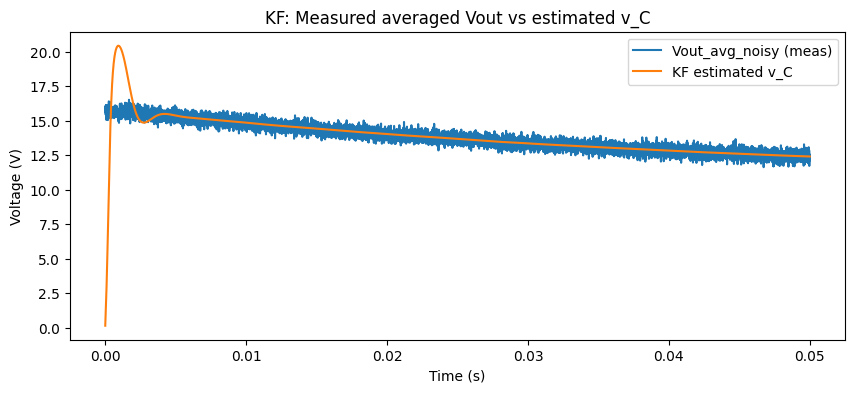

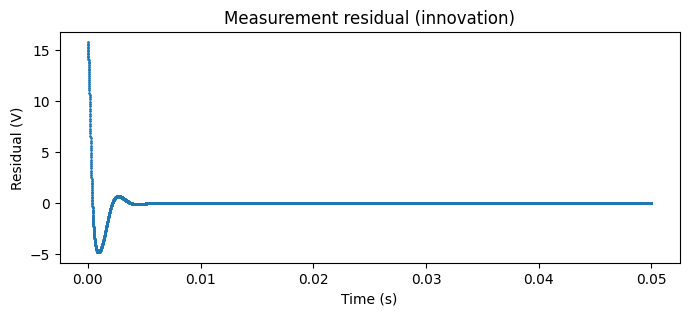

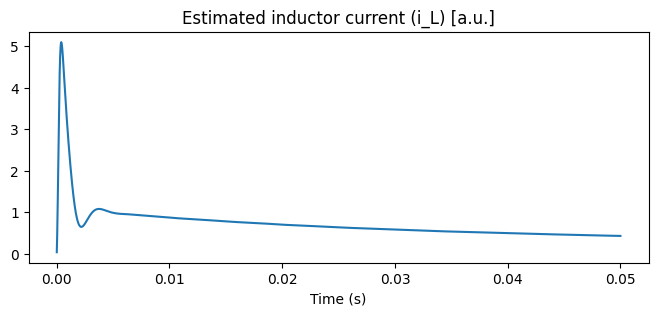

In [51]:
plt.figure(figsize=(10,4))
plt.plot(t_avg, Y_n, label='Vout_avg_noisy (meas)')
plt.plot(t_avg, x_hat_hist[:,1], label='KF estimated v_C')
plt.legend(); plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('KF: Measured averaged Vout vs estimated v_C'); plt.show()

# Residual plot
plt.figure(figsize=(8,3))
plt.plot(t_avg, residuals, '.', markersize=2)
plt.title('Measurement residual (innovation)')
plt.xlabel('Time (s)'); plt.ylabel('Residual (V)'); plt.show()

# Example: inspect estimated i_L
plt.figure(figsize=(8,3))
plt.plot(t_avg, x_hat_hist[:,0])
plt.title('Estimated inductor current (i_L) [a.u.]'); plt.xlabel('Time (s)'); plt.show()


PARAMETER DRIFT (AGING)

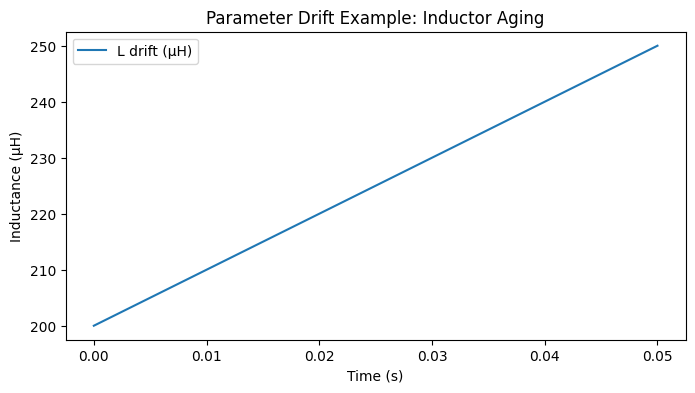

In [52]:
# Let's say L drifts from 200 µH to 250 µH over time
L_nom = 200e-6
L_drift = L_nom * (1 + 0.25 * (t_avg / max(t_avg)))  # linear drift of +25%

plt.figure(figsize=(8,4))
plt.plot(t_avg
         , L_drift*1e6, label="L drift (µH)")
plt.title("Parameter Drift Example: Inductor Aging")
plt.xlabel("Time (s)")
plt.ylabel("Inductance (µH)")
plt.legend(); plt.show()


In [53]:
# Colab cell
def run_time_varying_kf(Y, U, Ad_list, Bd_list, Cd, Q=None, Rk=None, x0=None, P0=None):
    K = len(Y)
    n_states = Ad_list[0].shape[0]
    if x0 is None:
        x_hat = np.zeros((n_states,))
    else:
        x_hat = x0.copy()
    if P0 is None:
        P = np.eye(n_states) * 1e-3
    else:
        P = P0.copy()
    if Q is None:
        Q = np.eye(n_states) * 1e-6
    if Rk is None:
        meas_var_emp = np.var(Y.flatten(), ddof=1)
        Rk = np.array([[max(meas_var_emp/10.0, 1e-6)]])   # conservative fallback

    x_hat_hist = np.zeros((K, n_states))
    P_hist = np.zeros((K, n_states, n_states))
    residuals = np.zeros((K, 1))

    for k in range(K):
        Ad = Ad_list[k]
        Bd = Bd_list[k]
        uk = np.array([U[k,0]])
        # predict
        x_pred = Ad.dot(x_hat) + Bd.dot(uk)
        P_pred = Ad.dot(P).dot(Ad.T) + Q
        # update
        y_pred = Cd.dot(x_pred).reshape(-1)
        sk = Cd.dot(P_pred).dot(Cd.T) + Rk
        Kk = P_pred.dot(Cd.T).dot(np.linalg.inv(sk))
        y_meas = Y[k].reshape(-1)
        innov = y_meas - y_pred
        x_hat = x_pred + (Kk.dot(innov)).flatten()
        P = (np.eye(n_states) - Kk.dot(Cd)).dot(P_pred)
        # store
        x_hat_hist[k,:] = x_hat
        P_hist[k,:,:] = P
        residuals[k,:] = innov

    return x_hat_hist, P_hist, residuals


In [54]:
# Colab cell
def inject_step_anomaly(signal, t_avg, t0, duration, magnitude, mode='add'):
    """
    Add a step/dip between times [t0, t0+duration].
    mode: 'add' -> add magnitude; 'mul' -> multiply by magnitude (1.0 +/-)
    magnitude: for add -> volts; for mul -> scale factor (eg 0.8 for 20% dip)
    """
    sig = signal.copy()
    mask = (t_avg >= t0) & (t_avg < (t0 + duration))
    if mode == 'add':
        sig[mask] += magnitude
    elif mode == 'mul':
        sig[mask] *= magnitude
    return sig, mask

def inject_spikes(signal, t_avg, spike_times, spike_mags):
    """
    spike_times: list of times
    spike_mags: list of magnitudes to add
    """
    sig = signal.copy()
    mask_total = np.zeros_like(sig, dtype=bool)
    for tt, mag in zip(spike_times, spike_mags):
        idx = np.argmin(np.abs(t_avg - tt))
        sig[idx] += mag
        mask_total[idx] = True
    return sig, mask_total

def inject_sine_drift(signal, t_avg, amp, freq):
    """Low-frequency oscillatory degradation added to signal."""
    sig = signal.copy()
    sig += amp * np.sin(2*np.pi*freq*t_avg)
    return sig

def drift_parameter_vector(vec, t_avg, final_factor=1.25, kind='linear'):
    """
    Create a drifted parameter vector of same length as vec.
    final_factor: multiply original by this factor at end (e.g., 1.25 = +25%)
    kind: 'linear' or 'expo'
    """
    K = len(vec)
    if kind == 'linear':
        factors = 1.0 + (final_factor - 1.0) * (t_avg - t_avg.min()) / (t_avg.max() - t_avg.min())
    else:
        # simple expo drift
        factors = 1.0 + (final_factor - 1.0) * (np.exp((t_avg - t_avg.min())/(t_avg.max()-t_avg.min())) - 1.0) / (np.e - 1.0)
    return vec * factors


In [55]:
# Simulate discrete-time time-varying LTI (per-step Ad_list, Bd_list) plant
def simulate_time_varying_plant(Ad_list, Bd_list, Cd, U, x0=None, process_noise_std=0.0, meas_noise_std=0.0, random_seed=0):
    """
    Ad_list, Bd_list : lists length K of matrices
    Cd : measurement matrix (1x2)
    U : (K,1) input sequence (e.g. duty or Vin-based input if Bd built with Vin)
    returns x_hist: (K, n_states), y_hist: (K,1)
    """
    rng = np.random.default_rng(random_seed)
    K = len(Ad_list)
    n_states = Ad_list[0].shape[0]
    if x0 is None:
        x = np.zeros((n_states,))
    else:
        x = x0.copy()
    x_hist = np.zeros((K, n_states))
    y_hist = np.zeros((K, 1))
    for k in range(K):
        Ad = Ad_list[k]
        Bd = Bd_list[k]
        uk = np.atleast_1d(U[k]).reshape(-1,1)
        # process noise
        w = rng.normal(scale=process_noise_std, size=(n_states,))
        x = (Ad.dot(x) + (Bd.dot(uk)).flatten()) + w
        # measurement
        v = rng.normal(scale=meas_noise_std, size=(1,))
        y = Cd.dot(x).reshape(1,) + v
        x_hist[k,:] = x
        y_hist[k,0] = y
    return x_hist, y_hist


/tmp/ipython-input-1845047893.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hist[k,0] = y


Experiment A (revised) metrics (compare KF estimate vs true plant): {'rmse': np.float64(0.3130233624959798), 'mae': 0.1262855433224395, 'mape_pct': np.float64(1.5054666577189104), 'nrmse': np.float64(0.01213451483309124)}


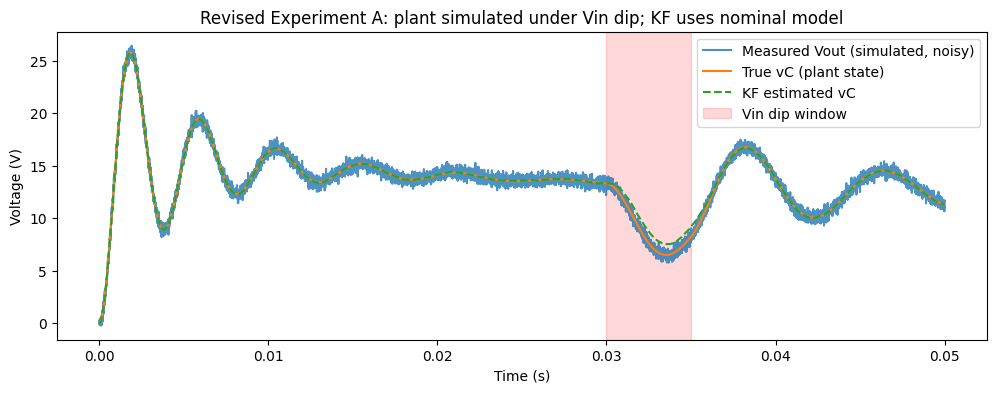

In [56]:
# Experiment A (revised): create Vin anomaly, rebuild Bd_true, simulate plant, then run KF (which uses nominal model)
# --- create modified Vin (multiplicative dip) ---
t0 = 0.03
duration = 0.005
Vin_avg_mod, mask = inject_step_anomaly(Vin_avg.copy(), t_avg, t0, duration, magnitude=0.7, mode='mul')  # 30% sag

# --- Build Bd_true using modified Vin_avg_mod (Ad_true may use nominal L,C,R or also modified if you want) ---
Bd_true = []
Ad_true = []   # we'll keep Ad_true same as nominal or modify if testing parameter change
for k in range(len(Vout_avg)):
    Lk = L_avg[k] if L_avg[k] > 0 else L_avg.max()
    Ck = C_avg[k] if C_avg[k] > 0 else C_avg.max()
    Rk = R_avg[k] if R_avg[k] > 0 else R_avg.max()
    Vin_k = Vin_avg_mod[k]
    Ac = np.array([[0.0, -1.0 / Lk],
                   [1.0 / Ck, -1.0 / (Rk * Ck)]])
    Bc = np.array([[Vin_k / Lk],
                   [0.0]])
    sysd = cont2discrete((Ac, Bc, Cd, Dd0), Ts, method='zoh')
    Ad_true.append(sysd[0])
    Bd_true.append(sysd[1])

# --- Simulate the true plant with small process noise and measurement noise ---
#   choose sensible stds: process noise small (e.g., 1e-4 on states), measurement noise similar to your earlier R estimate
process_noise_std = 1e-5
meas_noise_std = np.sqrt(np.mean(Vout_var)) / np.sqrt(N_per)  # rough; tune as needed
# Input U for simulation: must match whatever U the plant uses; your earlier pipeline used D_est; use same shape
U_sim = D_est.reshape(-1,1)

x_true_hist, Vout_sim = simulate_time_varying_plant(Ad_true, Bd_true, Cd, U_sim,
                                                    process_noise_std=process_noise_std,
                                                    meas_noise_std=meas_noise_std,
                                                    x0=None, random_seed=1)

# --- Now run KF using nominal Ad_list and Bd_list (i.e. model mismatch) ---
Q = np.diag([1e-6, 1e-6])
Rk = np.array([[meas_noise_std**2 + 1e-8]])
x_hat_hist, P_hist, residuals = run_time_varying_kf(Vout_sim, U_sim, Ad_list, Bd_list, Cd, Q=Q, Rk=Rk)

# --- Evaluate using the *true simulated* v_C (state index 1) vs KF estimate ---
vC_true = x_true_hist[:,1]
vC_est  = x_hat_hist[:,1]
metrics = compute_metrics(vC_true, vC_est)
print("Experiment A (revised) metrics (compare KF estimate vs true plant):", metrics)

# --- plots: measured (simulated noisy Vout), true state vC, KF estimate ---
plt.figure(figsize=(12,4))
plt.plot(t_avg, Vout_sim.flatten(), label='Measured Vout (simulated, noisy)', alpha=0.8)
plt.plot(t_avg, vC_true, label='True vC (plant state)')
plt.plot(t_avg, vC_est, '--', label='KF estimated vC')
plt.axvspan(t0, t0+duration, color='red', alpha=0.15, label='Vin dip window')
plt.legend(); plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('Revised Experiment A: plant simulated under Vin dip; KF uses nominal model')
plt.show()



/tmp/ipython-input-1845047893.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hist[k,0] = y


Experiment B metrics: {'rmse': np.float64(0.024911568880406732), 'mae': 0.019942492679713333, 'mape_pct': np.float64(0.21461305310103562), 'nrmse': np.float64(0.0009657116060620599)}


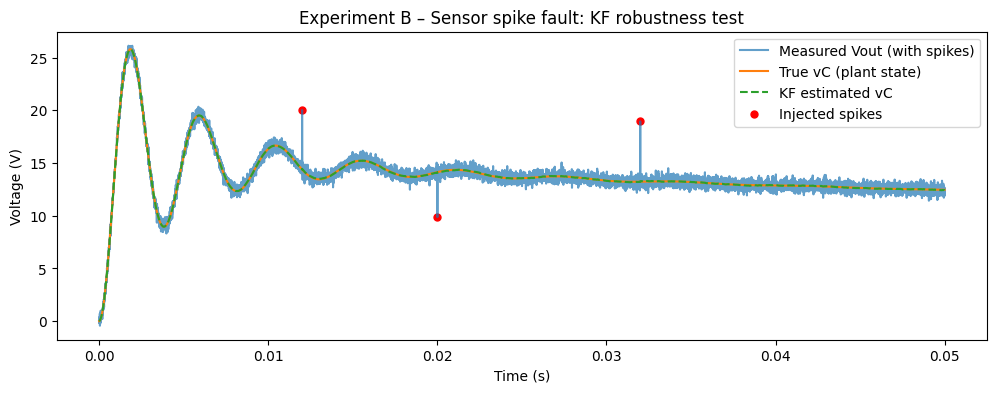

In [58]:
# ===============================================================
# Experiment B: Sensor spike fault — simulate clean plant, then
# inject spikes only in measurement (Vout)
# ===============================================================

# --- Step 1: Simulate true plant with nominal Ad/Bd (no fault) ---
U_sim = D_est.reshape(-1,1)
process_noise_std = 1e-5
meas_noise_std = np.sqrt(np.mean(Vout_var)) / np.sqrt(N_per)

x_true_hist_B, Vout_sim_B = simulate_time_varying_plant(
    Ad_list, Bd_list, Cd, U_sim,
    process_noise_std=process_noise_std,
    meas_noise_std=meas_noise_std,
    x0=None, random_seed=2
)

# --- Step 2: Inject sensor spikes into measurement only ---
spike_times = [0.012, 0.020, 0.032]   # example spike times
spike_mags  = [5.0, -4.5, 6.0]        # voltage spikes (+/-)
Vout_spike_B, spike_mask = inject_spikes(Vout_sim_B.flatten(), t_avg, spike_times, spike_mags)
Vout_spike_B = Vout_spike_B.reshape(-1,1)

# --- Step 3: Run KF using nominal model ---
Q = np.diag([1e-6, 1e-6])
Rk = np.array([[meas_noise_std**2 + 1e-8]])
x_hat_hist_B, _, residuals_B = run_time_varying_kf(Vout_spike_B, U_sim, Ad_list, Bd_list, Cd, Q=Q, Rk=Rk)

# --- Step 4: Evaluate performance against true state vC ---
vC_true_B = x_true_hist_B[:,1]
vC_est_B  = x_hat_hist_B[:,1]
metrics_B = compute_metrics(vC_true_B, vC_est_B)
print("Experiment B metrics:", metrics_B)

# --- Step 5: Plot ---
plt.figure(figsize=(12,4))
plt.plot(t_avg, Vout_spike_B, label='Measured Vout (with spikes)', alpha=0.7)
plt.plot(t_avg, vC_true_B, label='True vC (plant state)')
plt.plot(t_avg, vC_est_B, '--', label='KF estimated vC')
plt.scatter(t_avg[spike_mask], Vout_spike_B[spike_mask], color='red', s=25, label='Injected spikes')
plt.legend(); plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('Experiment B – Sensor spike fault: KF robustness test')
plt.show()



/tmp/ipython-input-1845047893.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hist[k,0] = y


Experiment C metrics: {'rmse': np.float64(0.12860538906486332), 'mae': 0.09366591955601285, 'mape_pct': np.float64(0.6605542792209195), 'nrmse': np.float64(0.004982836525078067)}


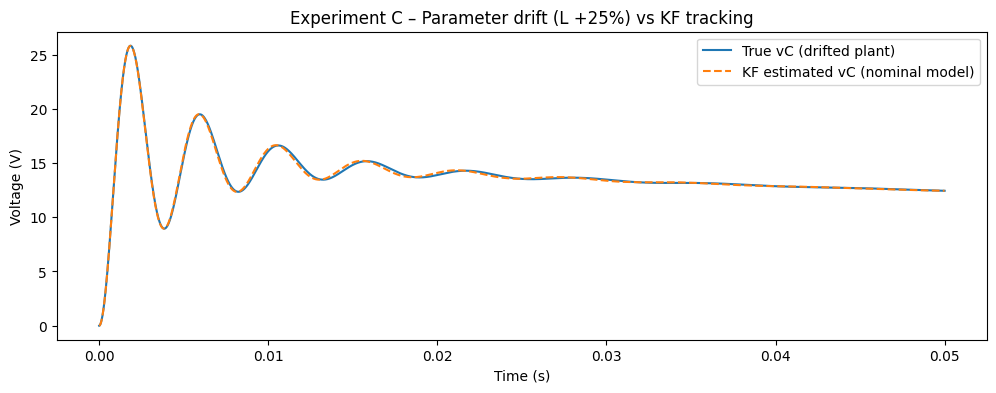

In [59]:
# ===============================================================
# Experiment C: Parameter drift – inductor L slowly increases (+25%)
# ===============================================================

# --- Step 1: Create drifted L vector and build true Ad/Bd ---
L_drifted = drift_parameter_vector(L_avg, t_avg, final_factor=1.25, kind='linear')
Ad_true_C, Bd_true_C = [], []
for k in range(len(Vout_avg)):
    Lk, Ck, Rk = L_drifted[k], C_avg[k], R_avg[k]
    Vin_k = Vin_avg[k]
    Ac = np.array([[0.0, -1.0/Lk],
                   [1.0/Ck, -1.0/(Rk*Ck)]])
    Bc = np.array([[Vin_k/Lk],
                   [0.0]])
    sysd = cont2discrete((Ac,Bc,Cd,Dd0), Ts, method='zoh')
    Ad_true_C.append(sysd[0]);  Bd_true_C.append(sysd[1])

# --- Step 2: Simulate plant with drifted parameters (true system) ---
x_true_hist_C, Vout_sim_C = simulate_time_varying_plant(
    Ad_true_C, Bd_true_C, Cd, U_sim,
    process_noise_std=1e-5, meas_noise_std=meas_noise_std, random_seed=3
)

# --- Step 3: Run KF using *nominal* model (no drift compensation) ---
x_hat_hist_C, _, residuals_C = run_time_varying_kf(Vout_sim_C, U_sim, Ad_list, Bd_list, Cd, Q=Q, Rk=Rk)

# --- Step 4: Evaluate performance ---
vC_true_C = x_true_hist_C[:,1]
vC_est_C  = x_hat_hist_C[:,1]
metrics_C = compute_metrics(vC_true_C, vC_est_C)
print("Experiment C metrics:", metrics_C)

# --- Step 5: Plot ---
plt.figure(figsize=(12,4))
plt.plot(t_avg, vC_true_C, label='True vC (drifted plant)')
plt.plot(t_avg, vC_est_C, '--', label='KF estimated vC (nominal model)')
plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('Experiment C – Parameter drift (L +25%) vs KF tracking')
plt.legend(); plt.show()

/tmp/ipython-input-1845047893.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y_hist[k,0] = y


Experiment D metrics: {'rmse': np.float64(1.1130040997819675), 'mae': 0.5821683159316156, 'mape_pct': np.float64(5.006087046704485), 'nrmse': np.float64(0.04312714652220514)}


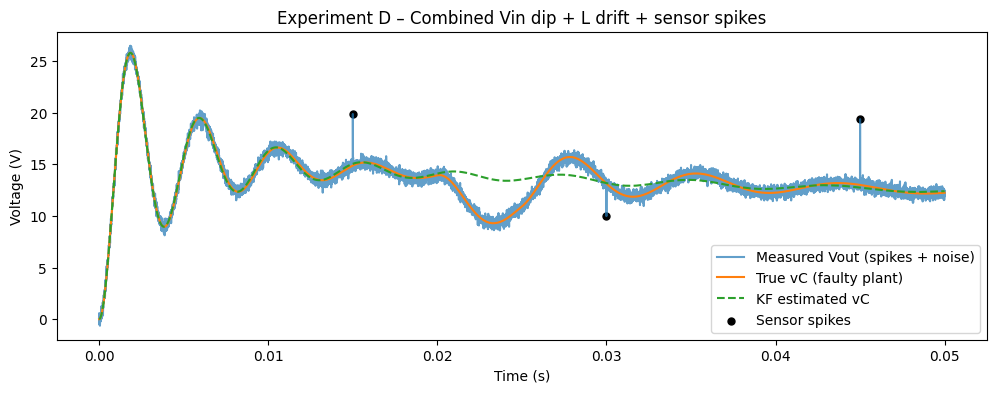

In [33]:
# ===============================================================
# Experiment D: Combined anomaly scenario
#  – Vin dip (input fault)
#  – L drift (+20%)
#  – Sensor spikes in measurement
# ===============================================================

# --- Step 1: Combine input dip + parameter drift in plant ---
t0, duration = 0.02, 0.005
Vin_avg_mod_D, _ = inject_step_anomaly(Vin_avg.copy(), t_avg, t0, duration, magnitude=0.8, mode='mul')  # 20% dip
L_drifted_D = drift_parameter_vector(L_avg, t_avg, final_factor=1.20, kind='linear')

Ad_true_D, Bd_true_D = [], []
for k in range(len(Vout_avg)):
    Lk, Ck, Rk = L_drifted_D[k], C_avg[k], R_avg[k]
    Vin_k = Vin_avg_mod_D[k]
    Ac = np.array([[0.0, -1.0/Lk],
                   [1.0/Ck, -1.0/(Rk*Ck)]])
    Bc = np.array([[Vin_k/Lk],
                   [0.0]])
    sysd = cont2discrete((Ac,Bc,Cd,Dd0), Ts, method='zoh')
    Ad_true_D.append(sysd[0]);  Bd_true_D.append(sysd[1])

# --- Step 2: Simulate plant with combined faults (true system) ---
x_true_hist_D, Vout_sim_D = simulate_time_varying_plant(
    Ad_true_D, Bd_true_D, Cd, U_sim,
    process_noise_std=1e-5, meas_noise_std=meas_noise_std, random_seed=4
)

# --- Step 3: Inject sensor spikes post-simulation ---
spike_times_D = [0.015, 0.03, 0.045]
spike_mags_D  = [5.0, -3.5, 6.0]
Vout_spike_D, spike_mask_D = inject_spikes(Vout_sim_D.flatten(), t_avg, spike_times_D, spike_mags_D)
Vout_spike_D = Vout_spike_D.reshape(-1,1)

# --- Step 4: Run KF (nominal model) ---
x_hat_hist_D, _, residuals_D = run_time_varying_kf(Vout_spike_D, U_sim, Ad_list, Bd_list, Cd, Q=Q, Rk=Rk)

# --- Step 5: Evaluate ---
vC_true_D = x_true_hist_D[:,1]
vC_est_D  = x_hat_hist_D[:,1]
metrics_D = compute_metrics(vC_true_D, vC_est_D)
print("Experiment D metrics:", metrics_D)

# --- Step 6: Plot results ---
plt.figure(figsize=(12,4))
plt.plot(t_avg, Vout_spike_D, label='Measured Vout (spikes + noise)', alpha=0.7)
plt.plot(t_avg, vC_true_D, label='True vC (faulty plant)')
plt.plot(t_avg, vC_est_D, '--', label='KF estimated vC')
#plt.axvspan(t0, t0+duration, color='red', alpha=0.15, label='Vin dip window')
plt.scatter(t_avg[spike_mask_D], Vout_spike_D[spike_mask_D], color='black', s=25, label='Sensor spikes')
plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('Experiment D – Combined Vin dip + L drift + sensor spikes')
plt.legend(); plt.show()


In [60]:
import numpy as np
import matplotlib.pyplot as plt

# EKF model: nonlinear plant dynamics for Buck converter
def f_nonlinear(x, u, params):
    iL, vC = x
    D, Vin = u  # inputs
    L, C, R, rL = params
    diL_dt = (D * Vin - vC - rL * iL) / L
    dvC_dt = (iL - vC / R) / C
    return np.array([iL + Ts * diL_dt, vC + Ts * dvC_dt])  # simple Euler integration

def h_nonlinear(x):
    # measured output = capacitor voltage
    return np.array([x[1]])

def jacobians(x, u, params):
    """Compute Jacobians F = df/dx, H = dh/dx"""
    iL, vC = x
    D, Vin = u
    L, C, R, rL = params

    # ∂f/∂x
    F = np.array([
        [1 - Ts * rL / L, -Ts / L],
        [Ts / C, 1 - Ts / (R * C)]
    ])

    # ∂h/∂x
    H = np.array([[0, 1]])
    return F, H

def run_ekf(Y, U, Vin_seq, params_nom, Q, R, x0=None):
    n = 2
    K = len(Y)
    if x0 is None:
        x_hat = np.zeros((n,))
    else:
        x_hat = x0.copy()
    P = np.eye(n) * 1e-3

    x_hat_hist = np.zeros((K, n))
    residuals = np.zeros((K, 1))

    for k in range(K):
        # predict
        uk = np.array([U[k,0], Vin_seq[k]])
        x_pred = f_nonlinear(x_hat, uk, params_nom)
        Fk, Hk = jacobians(x_hat, uk, params_nom)
        P_pred = Fk @ P @ Fk.T + Q

        # measurement update
        y_pred = h_nonlinear(x_pred)
        Sk = Hk @ P_pred @ Hk.T + R
        Kk = P_pred @ Hk.T @ np.linalg.inv(Sk)
        innov = Y[k] - y_pred
        x_hat = x_pred + (Kk @ innov).flatten()
        P = (np.eye(n) - Kk @ Hk) @ P_pred

        x_hat_hist[k,:] = x_hat
        residuals[k,:] = innov

    return x_hat_hist, residuals


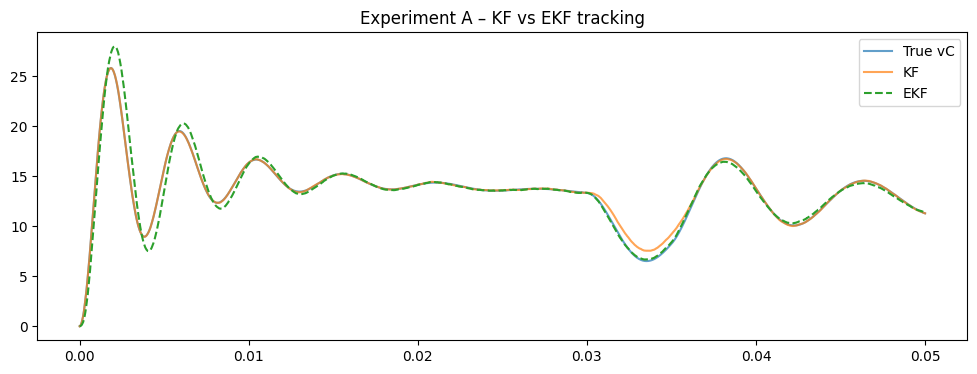

KF metrics: {'rmse': np.float64(0.3130233624959798), 'mae': 0.1262855433224395, 'mape_pct': np.float64(1.5054666577189104), 'nrmse': np.float64(0.01213451483309124)}
EKF metrics: {'rmse': np.float64(0.8417964385563664), 'mae': 0.3988644041568417, 'mape_pct': np.float64(3.286793081355641), 'nrmse': np.float64(0.03263268047680243)}


In [61]:
# --- Prepare sequences ---
Y_ekf = Vout_sim.reshape(-1,1)       # simulated measurement from plant
U_ekf = D_est.reshape(-1,1)          # duty cycle
Vin_seq = Vin_avg_mod                # varying Vin due to dip

params_nom = [np.mean(L_avg), np.mean(C_avg), np.mean(R_avg), 0.01]  # [L, C, R, rL]
Q_ekf = np.diag([1e-6, 1e-6])
R_ekf = np.array([[meas_noise_std**2]])

x_hat_ekf, residuals_ekf = run_ekf(Y_ekf, U_ekf, Vin_seq, params_nom, Q_ekf, R_ekf)

# Compare EKF vs KF vs true
vC_true = x_true_hist[:,1]
plt.figure(figsize=(12,4))
plt.plot(t_avg, vC_true, label='True vC',alpha = 0.7)
plt.plot(t_avg, x_hat_hist[:,1], label='KF',alpha = 0.7)
plt.plot(t_avg, x_hat_ekf[:,1], '--', label='EKF')
#plt.axvspan(t0, t0+duration, color='red', alpha=0.15, label='Vin dip')
plt.legend(); plt.title('Experiment A – KF vs EKF tracking')
plt.show()

print("KF metrics:", compute_metrics(vC_true, x_hat_hist[:,1]))
print("EKF metrics:", compute_metrics(vC_true, x_hat_ekf[:,1]))


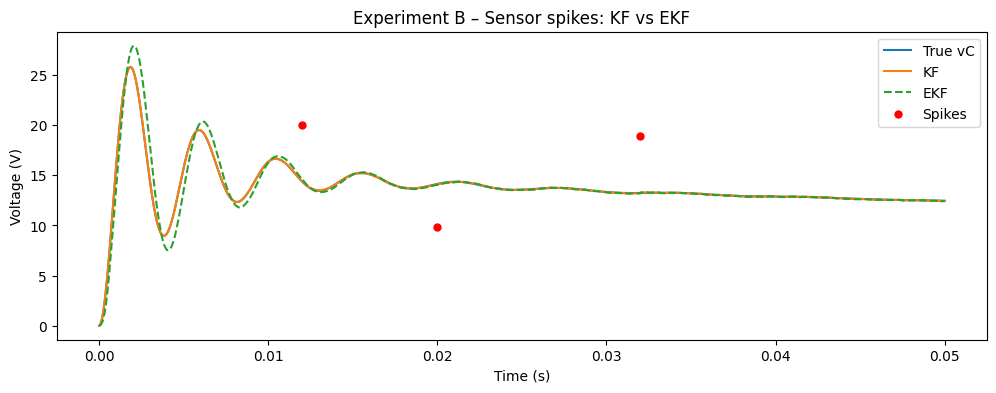

KF metrics : {'rmse': np.float64(0.024911568880406732), 'mae': 0.019942492679713333, 'mape_pct': np.float64(0.21461305310103562), 'nrmse': np.float64(0.0009657116060620599)}
EKF metrics: {'rmse': np.float64(0.8274996298802719), 'mae': 0.3324015550063693, 'mape_pct': np.float64(2.709785999874624), 'nrmse': np.float64(0.03207850940355508)}


In [64]:
# ===============================================================
# Experiment B: Sensor spike fault – EKF vs KF
# ===============================================================

# --- Prepare signals ---
Y_ekf_B = Vout_spike_B.reshape(-1,1)   # measurement with spikes
U_ekf_B = D_est.reshape(-1,1)          # duty ratio sequence
Vin_seq_B = Vin_avg                    # no Vin variation

# --- EKF parameters ---
params_nom = [np.mean(L_avg), np.mean(C_avg), np.mean(R_avg), 0.01]  # [L, C, R, rL]
Q_ekf = np.diag([1e-6, 1e-6])
R_ekf = np.array([[meas_noise_std**2]])

# --- Run EKF ---
x_hat_ekf_B, residuals_ekf_B = run_ekf(Y_ekf_B, U_ekf_B, Vin_seq_B, params_nom, Q_ekf, R_ekf)

# --- Compare KF vs EKF vs True ---
vC_true_B = x_true_hist_B[:,1]
plt.figure(figsize=(12,4))
plt.plot(t_avg, vC_true_B, label='True vC')
plt.plot(t_avg, x_hat_hist_B[:,1], label='KF')
plt.plot(t_avg, x_hat_ekf_B[:,1], '--', label='EKF')
plt.scatter(t_avg[spike_mask], Y_ekf_B[spike_mask], color='red', s=25, label='Spikes')
plt.legend(); plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('Experiment B – Sensor spikes: KF vs EKF')
plt.show()

print("KF metrics :", compute_metrics(vC_true_B, x_hat_hist_B[:,1]))
print("EKF metrics:", compute_metrics(vC_true_B, x_hat_ekf_B[:,1]))


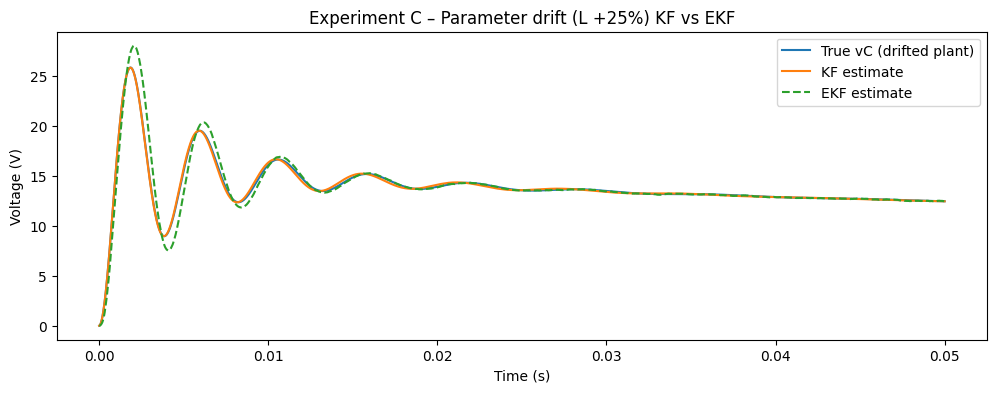

KF metrics : {'rmse': np.float64(0.12860538906486332), 'mae': 0.09366591955601285, 'mape_pct': np.float64(0.6605542792209195), 'nrmse': np.float64(0.004982836525078067)}
EKF metrics: {'rmse': np.float64(0.8131222512493607), 'mae': 0.32125847511006617, 'mape_pct': np.float64(2.667592442018393), 'nrmse': np.float64(0.0315045526656393)}


In [62]:
# ===============================================================
# Experiment C: Parameter drift (L +25%) – EKF vs KF
# ===============================================================

# --- Prepare signals ---
Y_ekf_C = Vout_sim_C.reshape(-1,1)
U_ekf_C = D_est.reshape(-1,1)
Vin_seq_C = Vin_avg  # Vin unchanged

# --- EKF parameters (nominal values) ---
params_nom = [np.mean(L_avg), np.mean(C_avg), np.mean(R_avg), 0.01]
Q_ekf = np.diag([1e-6, 1e-6])
R_ekf = np.array([[meas_noise_std**2]])

# --- Run EKF ---
x_hat_ekf_C, residuals_ekf_C = run_ekf(Y_ekf_C, U_ekf_C, Vin_seq_C, params_nom, Q_ekf, R_ekf)

# --- Compare KF vs EKF vs True ---
vC_true_C = x_true_hist_C[:,1]
plt.figure(figsize=(12,4))
plt.plot(t_avg, vC_true_C, label='True vC (drifted plant)')
plt.plot(t_avg, x_hat_hist_C[:,1], label='KF estimate')
plt.plot(t_avg, x_hat_ekf_C[:,1], '--', label='EKF estimate')
plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('Experiment C – Parameter drift (L +25%) KF vs EKF')
plt.legend(); plt.show()

print("KF metrics :", compute_metrics(vC_true_C, x_hat_hist_C[:,1]))
print("EKF metrics:", compute_metrics(vC_true_C, x_hat_ekf_C[:,1]))


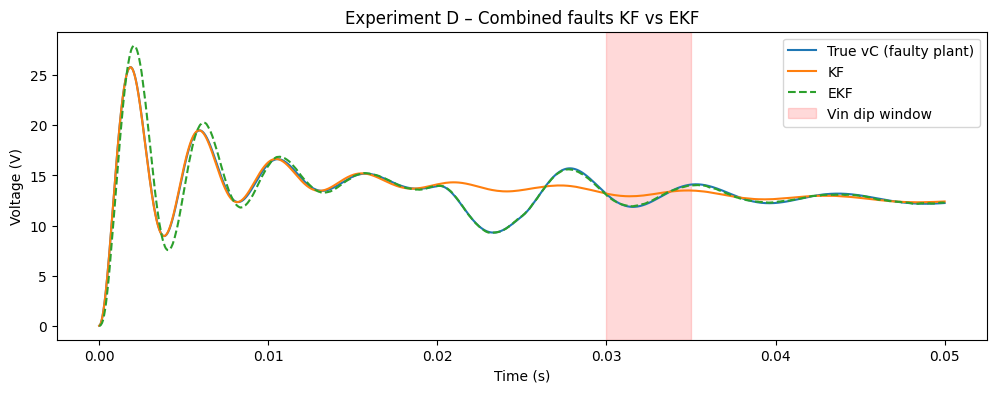

KF metrics : {'rmse': np.float64(1.1130040997819675), 'mae': 0.5821683159316156, 'mape_pct': np.float64(5.006087046704485), 'nrmse': np.float64(0.04312714652220514)}
EKF metrics: {'rmse': np.float64(0.8193935911244848), 'mae': 0.34534129831110966, 'mape_pct': np.float64(2.9083983930863537), 'nrmse': np.float64(0.031750204218209156)}


In [63]:
# ===============================================================
# Experiment D: Combined scenario (Vin dip + L drift + sensor spikes)
# ===============================================================

# --- Prepare signals ---
Y_ekf_D = Vout_spike_D.reshape(-1,1)   # measured with spikes
U_ekf_D = D_est.reshape(-1,1)
Vin_seq_D = Vin_avg_mod_D              # includes Vin dip

# --- EKF parameters ---
params_nom = [np.mean(L_avg), np.mean(C_avg), np.mean(R_avg), 0.01]
Q_ekf = np.diag([1e-6, 1e-6])
R_ekf = np.array([[meas_noise_std**2]])

# --- Run EKF ---
x_hat_ekf_D, residuals_ekf_D = run_ekf(Y_ekf_D, U_ekf_D, Vin_seq_D, params_nom, Q_ekf, R_ekf)

# --- Compare KF vs EKF vs True ---
vC_true_D = x_true_hist_D[:,1]
plt.figure(figsize=(12,4))
plt.plot(t_avg, vC_true_D, label='True vC (faulty plant)')
plt.plot(t_avg, x_hat_hist_D[:,1], label='KF')
plt.plot(t_avg, x_hat_ekf_D[:,1], '--', label='EKF')
plt.axvspan(t0, t0+duration, color='red', alpha=0.15, label='Vin dip window')
#plt.scatter(t_avg[spike_mask_D], Y_ekf_D[spike_mask_D], color='black', s=25, label='Sensor spikes')
plt.xlabel('Time (s)'); plt.ylabel('Voltage (V)')
plt.title('Experiment D – Combined faults KF vs EKF')
plt.legend(); plt.show()

print("KF metrics :", compute_metrics(vC_true_D, x_hat_hist_D[:,1]))
print("EKF metrics:", compute_metrics(vC_true_D, x_hat_ekf_D[:,1]))
